# Sanity Check
Testen, ob alle m6A modification positionen auch A sind

In [3]:
import gzip
import re
import csv
from src.util import load_region_modifications
from src.files.files import get_files

def sanity_check(fastaFile, regions):
    with fastaFile.open_or_recompute() as fastaFile:
        is_in_region = False
        has_region_modifications = False
        current_region_name = None
        current_region_modifications = None
        
        for line in fastaFile:
            if re.search(">", line):
                first_colon = line.find(":")
                
                is_in_region = True
                current_region_name = line[1:first_colon]
                current_region_modifications = []
                has_region_modifications = False
                if current_region_name in regions:
                    current_region_modifications = regions[current_region_name].modifications
                    if len(current_region_modifications):
                        has_region_modifications = True
            else:
                if not is_in_region:
                    continue
                if not has_region_modifications:
                    continue
                line_length = len(line)

                for modification in current_region_modifications:
                    if modification > line_length:
                        break

                    char = line[modification]

                    if char != "A" and char != "a":
                        print("Non A m6A!")

                current_region_modifications = filter(lambda modification: modification > line_length, current_region_modifications)
                current_region_modifications = [x - line_length for x in current_region_modifications]
                if len(current_region_modifications) == 0:
                    has_region_modifications = False

for key, file in get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict().items():
    print("Checking", key)
    regions = load_region_modifications(file)

    sanity_check(get_files().get_assembled_region_fasta_files().get_files_dict()[key], regions)

print("Done")

Checking 3utr
Checking 5utr
Checking 5utr_start
Checking cds
Checking coding_exons
Checking coding_introns
Checking exons
Checking introns
Checking non_coding_exons
Checking non_coding_introns
Done


# Sanity check windowing

NM_178857.6_exon
8014
[1688, 1707, 1770, 2658, 5402, 5412, 5429]
1538
5579


/home/erik/bio-prak/mypython/plot.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_504447/3847365759.py:138: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


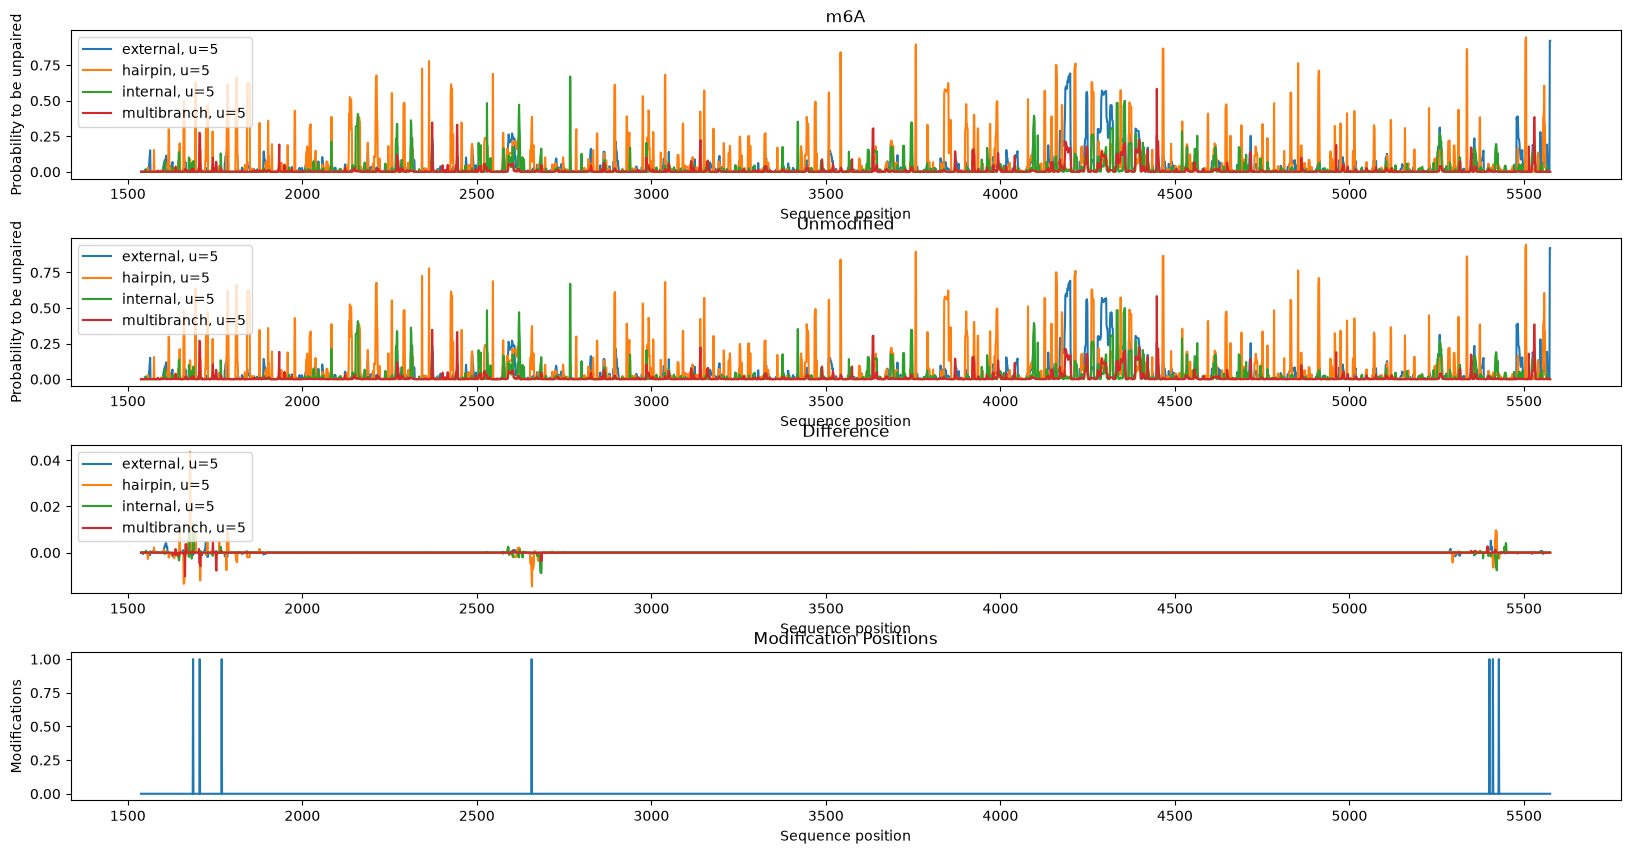

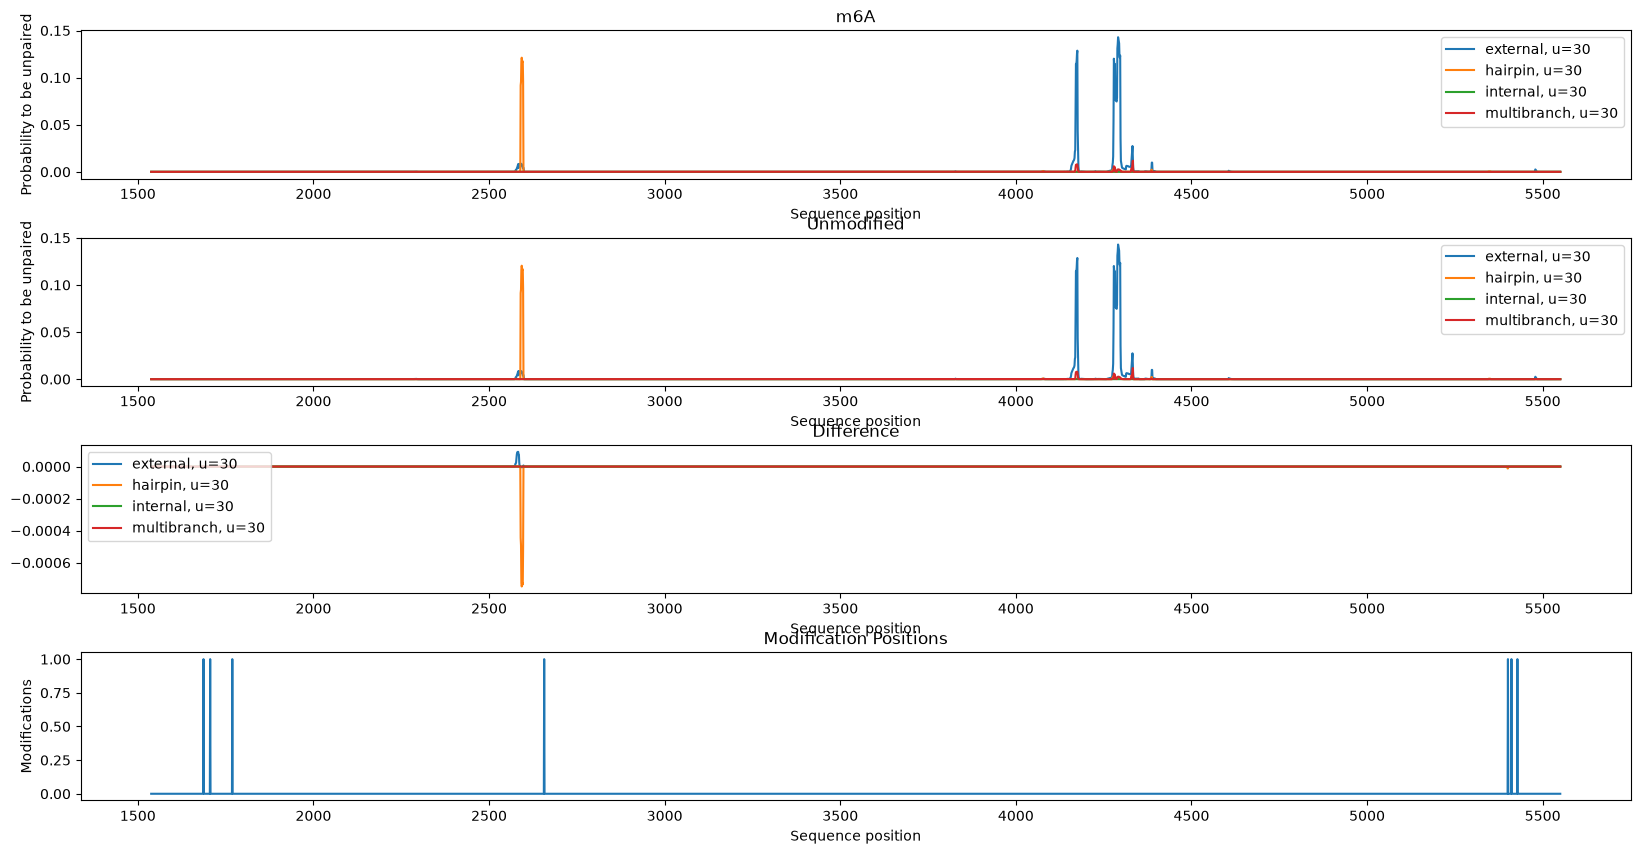

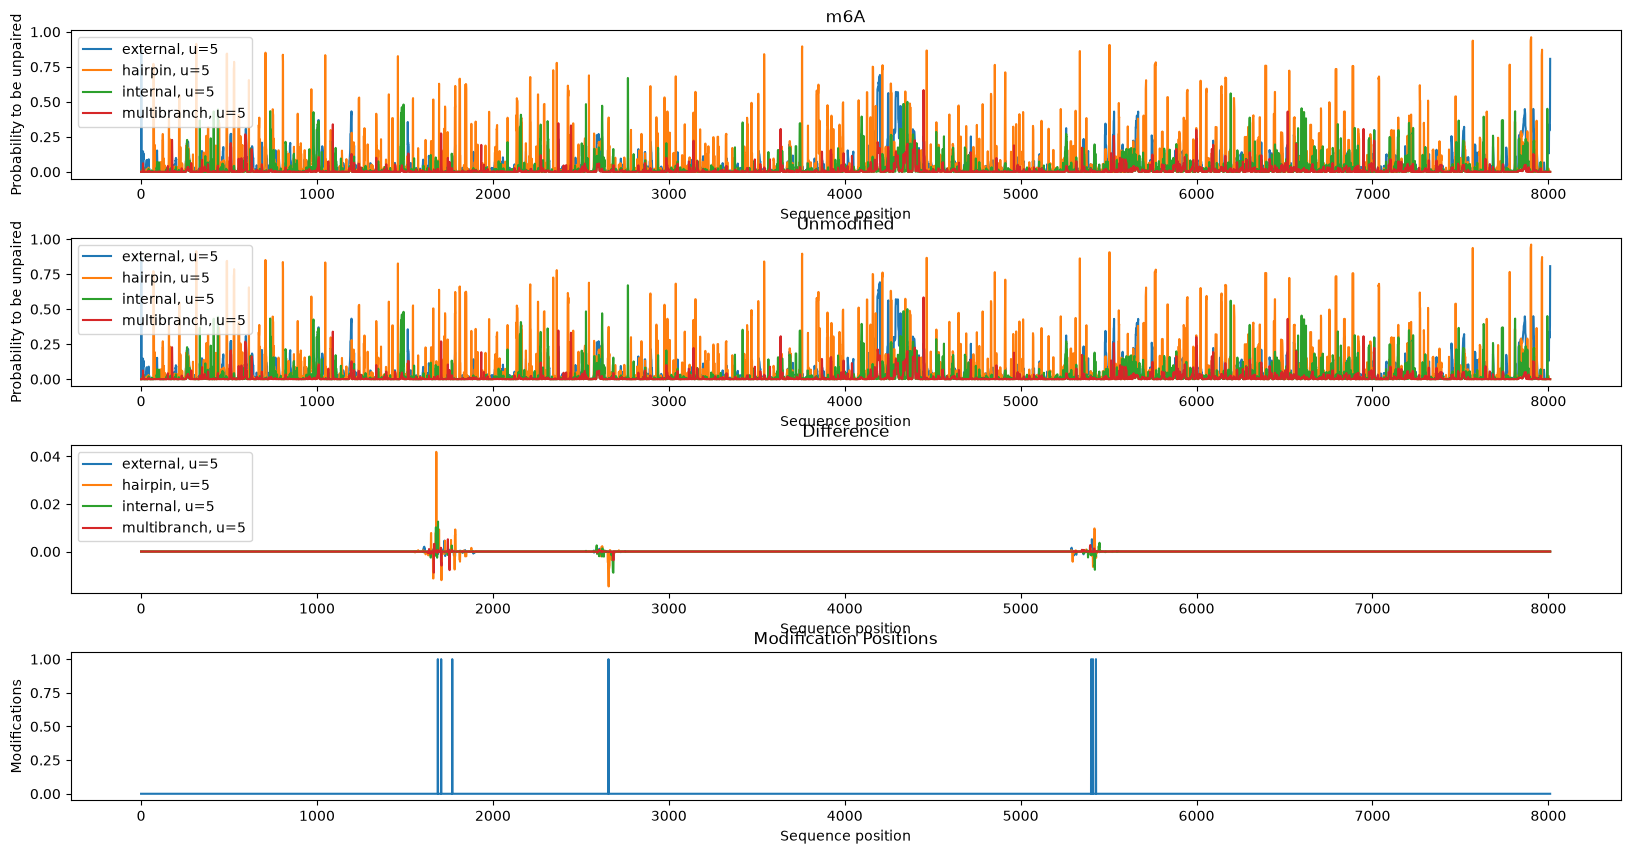

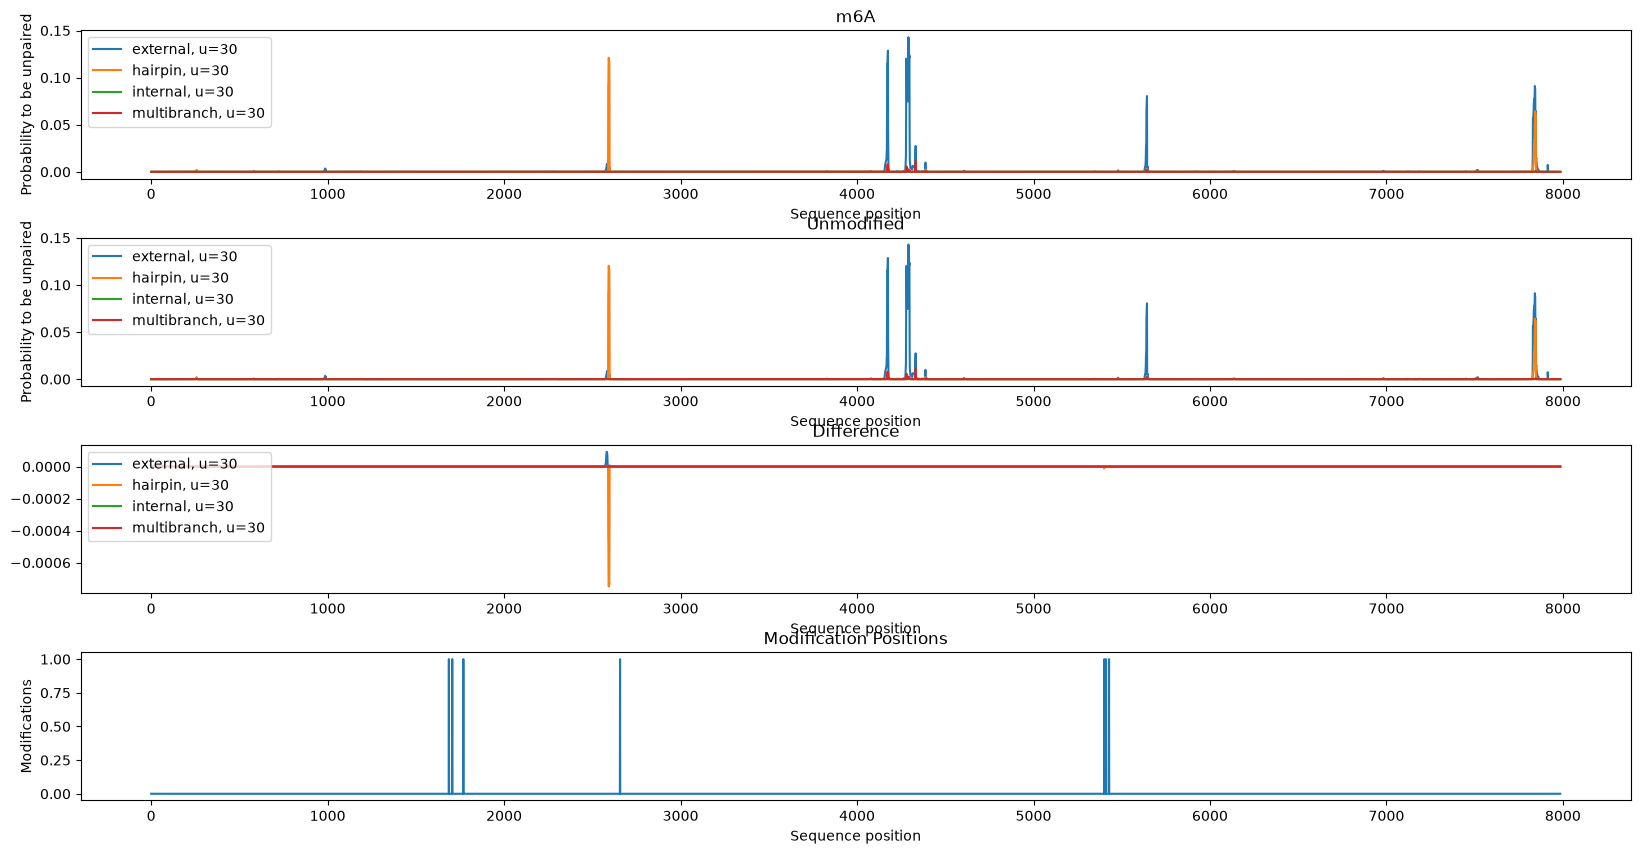

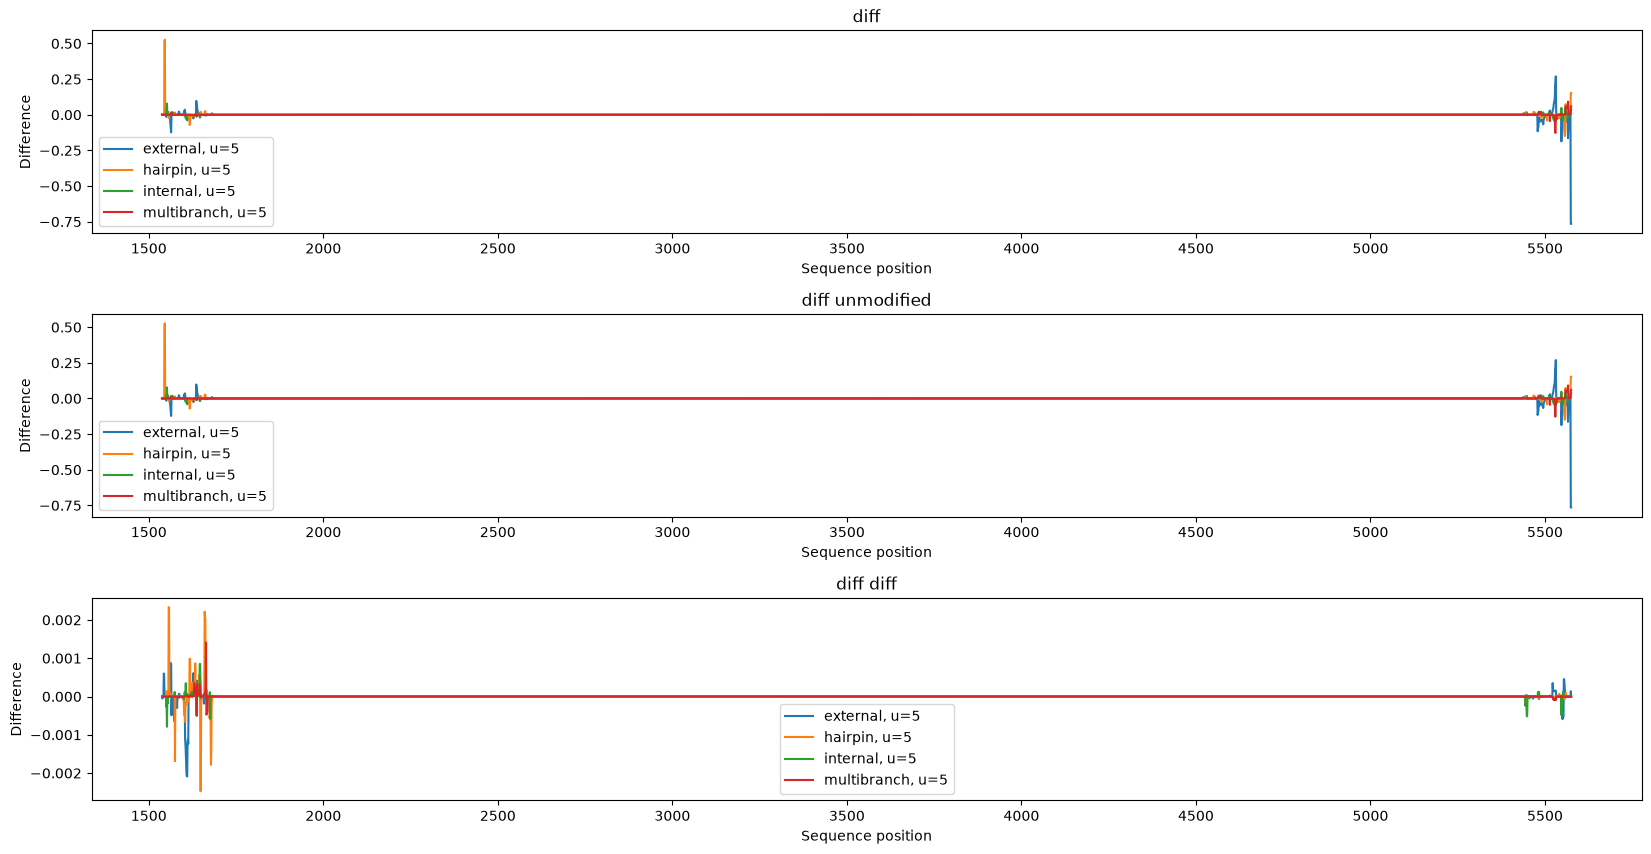

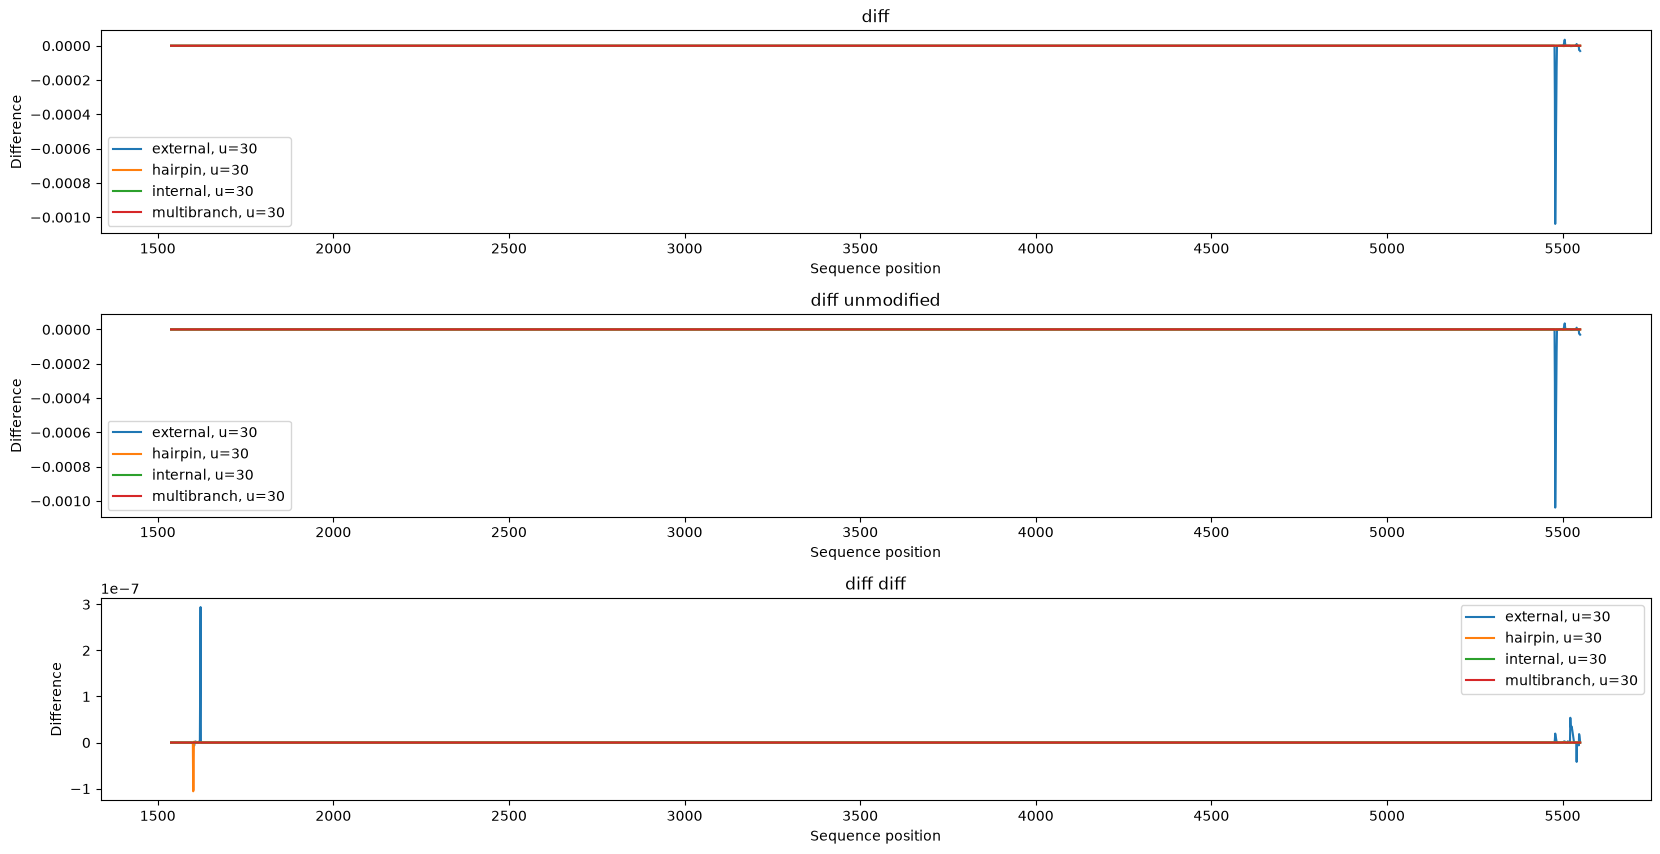

In [1]:
from mypython.algorithms import accessibility, looptypes
from mypython.plot import plot_accessibilities
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

fastaFile = get_files().get_assembled_region_fasta_files().get_exons_file()
fastaFile.open_or_recompute()

file = FASTA(fastaFile.get_possibly_gzip_path())
regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_exons_file())

footprints = [5, 30]
windowsize = 150
L = 100

slice_mult = 1

def map_entry(entry):
    region_name = entry.name[:entry.name.find(":")]
    sequence = str(entry.seq).upper().replace("T", "U")

    modifications = []
    
    if region_name in regions:
        modifications = regions[region_name].modifications

    return (region_name, sequence, modifications)

def filter_entry(entry):
    return len(entry[2]) != 0

def filter_length(entry):
    length = len(entry[1])
    return length > 8000 and length < 9000

def filter_start(entry):
    start = max(0, entry[2][0] - 2 * windowsize)
    return start != 0

def filter_end(entry):
    end = min(len(entry[1]), entry[2][len(entry[2]) - 1] + 2 * windowsize)
    return end != len(entry[1])

modified_regions =  filter(filter_end, filter(filter_start, filter(filter_length, filter(filter_entry, map(map_entry, file)))))

for _ in range(0):
    next(modified_regions)

for region_name, sequence, modifications in modified_regions:
    print(region_name)
    print(len(sequence))

    modifications = [x + 1 for x in modifications]
    modifications.sort()
    
    print(modifications)

    start = max(0, modifications[0] - int(windowsize * slice_mult))
    #start = 0
    end = min(len(sequence), modifications[len(modifications) - 1] + int(slice_mult * windowsize))
    #end = len(sequence)
    
    sequence_slice = sequence[start:end]
    modifications_slice = [x - start for x in modifications]
    print(start)
    print(end)
    data_slice_unmod = accessibility(sequence_slice, footprints, windowsize = windowsize, L = L)
    data_slice = accessibility(sequence_slice, footprints, windowsize = windowsize, L = L, m6A_sites = modifications_slice)

    plot_accessibilities(sequence_slice, footprints, looptypes, start, end, data_slice, data_slice_unmod, modifications_slice)

    data_unmod = accessibility(sequence, footprints, windowsize = windowsize, L = L)
    data = accessibility(sequence, footprints, windowsize = windowsize, L = L, m6A_sites = modifications)
    
    plot_accessibilities(sequence, footprints, looptypes, 0, len(sequence), data, data_unmod, modifications)

    diff_data_unmod = {}
    diff_data = {}
    diff_data_diff = {}

    for footprint in footprints:
        diff_fp_data_unmod = {}
        diff_fp_data = {}
        diff_fp_data_diff = {}
        for looptype in looptypes:
            diff_fp_data_unmod[looptype] = [0.0 for x in data_slice[footprint][looptype]]
            diff_fp_data[looptype] = [0.0 for x in data_slice[footprint][looptype]]
            diff_fp_data_diff[looptype] = [0.0 for x in data_slice[footprint][looptype]]
            
            for i in range(len(data_slice[footprint][looptype])):
                value = data[footprint][looptype][i + start]
                value_unmod = data_unmod[footprint][looptype][i + start]

                value_slice = data_slice[footprint][looptype][i]
                value_slice_unmod = data_slice_unmod[footprint][looptype][i]

                diff = value_unmod - value
                diff_slice = value_slice_unmod - value_slice
                
                diff_value = value - value_slice
                diff_value_unmod = value_unmod - value_slice_unmod

                diff_diff = diff - diff_slice

                diff_fp_data_unmod[looptype][i] = diff_value_unmod
                diff_fp_data[looptype][i] = diff_value
                diff_fp_data_diff[looptype][i] = diff_diff

        diff_data[footprint] = diff_fp_data
        diff_data_unmod[footprint] = diff_fp_data_unmod
        diff_data_diff[footprint] = diff_fp_data_diff

    
    for footprint in footprints:
        fig, axs = plt.subplots(3, sharey = False, figsize = (20, 10))
        for k, v in diff_data[footprint].items():
            axs[0].plot([i + start for i in range(len(sequence_slice) + 1 - footprint + 1)], v, label = "{}, u={:d}".format(looptypes[k], footprint))
        axs[0].set_title("diff")
        axs[0].set_xlabel("Sequence position")
        axs[0].set_ylabel("Difference")
        axs[0].legend()
        for k, v in diff_data_unmod[footprint].items():
            axs[1].plot([i + start for i in range(len(sequence_slice) + 1 - footprint + 1)], v, label = "{}, u={:d}".format(looptypes[k], footprint))
        axs[1].set_title("diff unmodified")
        axs[1].set_xlabel("Sequence position")
        axs[1].set_ylabel("Difference")
        axs[1].legend()
        for k, v in diff_data_diff[footprint].items():
            axs[2].plot([i + start for i in range(len(sequence_slice) + 1 - footprint + 1)], v, label = "{}, u={:d}".format(looptypes[k], footprint))
        axs[2].set_title("diff diff")
        axs[2].set_xlabel("Sequence position")
        axs[2].set_ylabel("Difference")
        axs[2].legend()

        fig.subplots_adjust(hspace=0.4)
        fig.show()
    break